In [1]:
# !pip install pauliopt

In [2]:
import numpy as np
from src.envs.generators import Circuits
from src.envs.diag_t import DiagT
# from numpy import random as rng
rng = np.random.RandomState(1337)

In [3]:
qubits = 10
steps = 1000

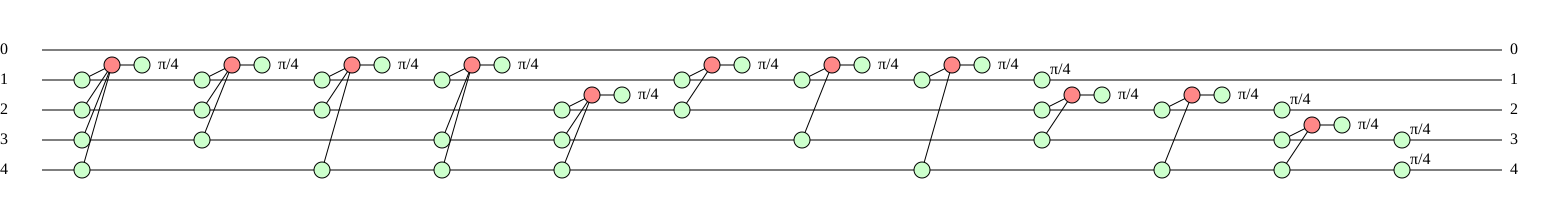

In [4]:
c = DiagT(5, ignore_cliffords=True).add_gadget(6, (1,2,3)).spider_nest((1,2,3,4))
c

In [5]:
c.is_id()

True

In [6]:
c = DiagT(5, ignore_cliffords=True).spider_nest((1,2,3,4)).spider_nest((0,1,2,3))
# c.spider_nest((1,2,3,4), k=7)
c.is_id()

True

In [7]:
c = DiagT(6, ignore_cliffords=True).spider_nest((1,2,3,4,0)).spider_nest((0,1,2,3)).add_gadget(2, (1, 2))
# c.spider_nest((1,2,3,4), k=7)
c.is_id()

True

In [8]:
# sample = gen.generate(rng)

steps = 1000

from pauliopt import phase as pauliopt

from pandas import Series

def random_walk_track(circ, steps, rng):
    sizes = []
    qubits = circ.n_qubits
    t = pauliopt.pi / 4
    orig_circ = circ.cloned()
    for _ in range(steps):
        size = rng.randint(4, min(circ.n_qubits, 8) + 1)
        qubits = rng.choice(range(circ.n_qubits), size=size, replace=False).tolist()
        times = rng.randint(1, 8)
        circ = circ.spider_nest(qubits, k=1)
        sizes.append(circ.n_gadgets)
    return sizes

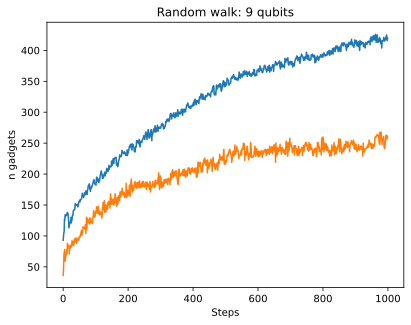

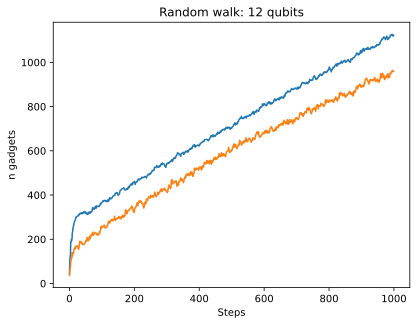

In [9]:
import matplotlib.pyplot as plt
for qubits in range(9, 15, 3):
    c1 = DiagT(qubits, ignore_cliffords=False)
    c2 = DiagT(qubits, ignore_cliffords=True)
    
    Series(random_walk_track(c1, steps, rng)).plot(xlabel='Steps', ylabel='n gadgets', title=f'Random walk: {qubits} qubits')
    Series(random_walk_track(c2, steps, rng)).plot(xlabel='Steps', ylabel='n gadgets')
    plt.show()

In [10]:
from itertools import combinations
from tqdm import tqdm

threshold = 200
# probability of growing
p_above = 0.01  # if above threshold
p_below = 0.3  # if below threshold
iter = 1000


def walk(n_qubits, iter):
    dict_sizes = []
    nest_sizes = []
    circ = DiagT(n_qubits, ignore_cliffords=True)
    dict_sizes.append(circ.n_gadgets)
    nest_sizes.append(len(circ.nests))
    no_match = 0
    last_move_grow = False
    for _ in tqdm(range(iter)):
        r = rng.random()
        p = p_below if circ.n_gadgets < threshold else p_above
        if r < p:
            grow(circ)
        else:
            if last_move_grow:
                v = shrink(circ)
                if not v:
                    no_match += 1
        last_move_grow = r < p
        last_move_grow = True
        dict_sizes.append(circ.n_gadgets)
        nest_sizes.append(len(circ.nests))
    print(f"{no_match=}")
    Series(dict_sizes).plot(xlabel='Steps', ylabel='n gadgets', title=f'Random walk: {n_qubits} qubits')
    Series(nest_sizes).plot(xlabel='Steps', ylabel='n gadgets', title=f'Random walk: {n_qubits} qubits')
    plt.show()
    return circ
        

def grow(circ, max_n=10):
    n = rng.randint(4, max_n + 1)
    qs = rng.choice(range(circ.n_qubits), size=n, replace=False).tolist()
    circ.spider_nest(qs)

def shrink(circ):
    for n in (4, 5):
        for qs in combinations(range(circ.n_qubits), n):
            n_gadgets = circ.n_gadgets
            circ.spider_nest(qs)
            if circ.n_gadgets < n_gadgets:
                return True
            circ.spider_nest(qs)
    return False

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [05:13<00:00,  3.19it/s]


no_match=620


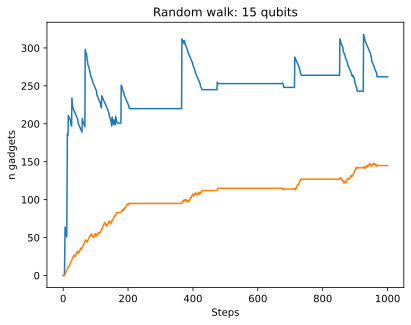

In [11]:
c0 = walk(15, 1000)

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [04:25<00:00,  3.77it/s]


no_match=437


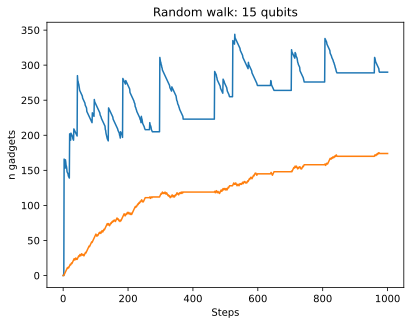

In [12]:
c1 = walk(15, 1000)

In [13]:
from collections import Counter
Counter([len(qs) for qs in c1._dict])

Counter({4: 118, 3: 98, 5: 38, 2: 15, 10: 5, 7: 4, 6: 4, 9: 3, 1: 3, 8: 2})

In [14]:
from math import comb
def n_bits(n):
    return n + comb(n, 2) + comb(n, 3) + 1

In [15]:
sum([n_bits(len(x)) for x in c1.nests])

4638

In [16]:
sum([DiagT(15, ignore_cliffords=False).spider_nest(x).n_gadgets for x in c1.nests])

4638

In [17]:
comb(15, 4)

1365

In [18]:
circ = DiagT(15)
counter = Counter([len(qs) for qs in c0.nests])
print(counter)
for n_q, n in counter.items():
    for _ in range(n):
        qs = rng.choice(range(circ.n_qubits), size=n_q, replace=False).tolist()
        while tuple(sorted(qs)) in circ.nests:
            qs = rng.choice(range(circ.n_qubits), size=n_q, replace=False).tolist()
        circ.spider_nest(qs)
print(sum([n_bits(len(x)) for x in circ.nests]))
print(circ.n_gadgets)
print(c0.n_gadgets)
print(Counter([len(qs) for qs in circ.nests]))

Counter({4: 106, 5: 23, 9: 6, 6: 3, 7: 3, 10: 2, 8: 2})
3824
438
262
Counter({4: 106, 5: 23, 9: 6, 7: 3, 6: 3, 8: 2, 10: 2})


In [19]:
circ = DiagT(15)
counter = Counter({4: 117})
print(counter)
for n_q, n in counter.items():
    for _ in range(n):
        qs = rng.choice(range(circ.n_qubits), size=n_q, replace=False).tolist()
        while tuple(sorted(qs)) in circ.nests:
            qs = rng.choice(range(circ.n_qubits), size=n_q, replace=False).tolist()
        circ.spider_nest(qs)
print(sum([n_bits(len(x)) for x in circ.nests]))
print(circ.n_gadgets)
print(c0.n_gadgets)
print(Counter([len(qs) for qs in circ.nests]))

Counter({4: 117})
1755
389
262
Counter({4: 117})


In [20]:
circ = DiagT(15)
for nest in c0.nests:
    circ.spider_nest(nest)
print(c0.n_gadgets)
print(circ.n_gadgets)

262
262


In [54]:
def gen(n_qubits, steps, rng):
    circ = DiagT(n_qubits)
    t = pauliopt.pi / 4
    for _ in tqdm(range(steps)):
        size = rng.randint(4, min(circ.n_qubits, 8) + 1)
        qubits = rng.choice(range(circ.n_qubits), size=size, replace=False).tolist()
        times = rng.randint(1, 8)
        circ = circ.spider_nest(qubits, k=1)
    items = list(circ._dict.items())
    np.random.shuffle(items)
    DiagT(n_qubits, dict(items[:len(items)//3]))
    DiagT(n_qubits, dict(items[len(items)//3:]))
    return circ

In [55]:
%%timeit

gen(10, 1000, rng)

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 6013.99it/s]

169 ms ± 4.03 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [36]:
# TODO move half the bits over

circ = gen(10, 1000, rng)

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 4862.47it/s]


In [49]:
items = list(circ._dict.items())
np.random.shuffle(items)
dict(items[:len(items)//3])
dict(items[len(items)//3:])

{(0, 3, 4, 6, 7, 9): 1,
 (0, 1, 2, 4, 5, 8): 1,
 (0, 1, 5, 7, 9): 1,
 (2, 3, 6): 1,
 (1, 3, 4, 6, 8): 1,
 (0, 1, 4, 5, 8, 9): 1,
 (3, 4, 5, 7, 8, 9): 1,
 (0, 1, 2, 3, 4): 1,
 (0, 1, 2, 4, 7, 9): 1,
 (3, 6, 8): 1,
 (1, 3, 5, 6, 7, 9): 1,
 (0, 1, 5, 6, 7, 9): 1,
 (2, 3, 5, 8, 9): 1,
 (1, 3, 5, 6, 8): 1,
 (7,): 1,
 (0, 1, 2, 4, 5, 6, 7): 1,
 (0, 4, 5, 6, 7): 1,
 (5, 6, 8): 1,
 (0, 1, 3, 7, 8): 1,
 (3, 4, 7, 8, 9): 1,
 (0, 2, 4): 1,
 (0, 1, 2, 3, 4, 6, 7, 8): 1,
 (1, 5, 7, 9): 1,
 (2, 5, 6, 7): 1,
 (0, 1, 3, 4, 5, 6, 8, 9): 1,
 (0, 3, 7, 9): 1,
 (4, 6, 7, 8): 1,
 (1, 2, 5, 7, 9): 1,
 (0, 2, 3, 5, 6, 7, 9): 1,
 (1, 2, 3, 5, 6, 8, 9): 1,
 (1, 3, 4, 6, 7, 8): 1,
 (0, 2, 4, 5, 6): 1,
 (0, 1, 2, 3, 5, 8, 9): 1,
 (1, 3, 5, 6, 7): 1,
 (0, 8, 9): 1,
 (0, 1, 3, 6, 7, 8): 1,
 (1, 3, 8): 1,
 (0, 1, 2, 3, 4, 5): 1,
 (2, 3, 4, 5, 6): 1,
 (0, 1, 2, 3, 4, 6, 9): 1,
 (0, 1, 2, 3, 6): 1,
 (0, 5, 6, 8): 1,
 (0, 2, 7, 8): 1,
 (0, 2, 5, 7, 9): 1,
 (1, 2, 4, 5, 7, 9): 1,
 (0, 1, 3, 4, 5, 9): 1,
 (0, 4, 5, 6, 9